[*********************100%***********************]  2 of 2 completed
<ipython-input-33-e2ea9869dda7>:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_PLTR = model.params[1]


                            OLS Regression Results                            
Dep. Variable:             PLTR_daily   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     244.1
Date:                Sun, 23 Mar 2025   Prob (F-statistic):           7.60e-48
Time:                        19:46:25   Log-Likelihood:                 1394.6
No. Observations:                 752   AIC:                            -2785.
Df Residuals:                     750   BIC:                            -2776.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -6.039e-05      0.001     -0.044      

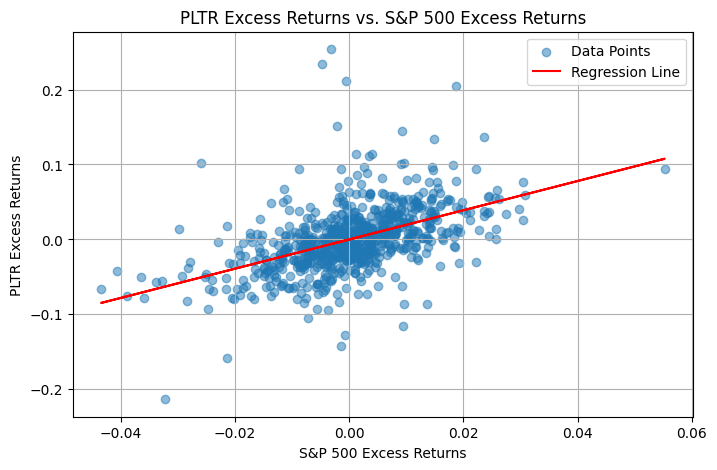

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize

#ASSIGNMENT 1: ESTIMATING BETA FOR A STOCK

#Task 1: Download historical price data for a chosen stock and the market index (e.g., S&P 500) from a financial data provider such as Yahoo Finance.

tickers = ['PLTR', '^GSPC']
data = yf.download(tickers, start='2021-01-01', end='2024-01-01')['Close']
data = data.dropna()

#Task 2: Calculate the stock's daily/weekly/monthly returns and the market index.

data['PLTR_daily'] = data['PLTR'].pct_change()
data['SP500_daily'] = data['^GSPC'].pct_change()

data['PLTR_weekly'] = data['PLTR'].pct_change(5)
data['SP500_weekly'] = data['^GSPC'].pct_change(5)

data['PLTR_monthly'] = data['PLTR'].pct_change(21)
data['SP500_monthly'] = data['^GSPC'].pct_change(21)

#Task 3: Use Python to perform a linear regression of the stock's excess return on the market's excess return to estimate the stock's beta.

#Assume 0.02% daily risk free rate

risk_free_rate = 0.0002
excess_PLTR_returns = data['PLTR_daily'] - risk_free_rate
excess_SP500_returns = data['SP500_daily'] - risk_free_rate

X = sm.add_constant(excess_SP500_returns)
model = sm.OLS(excess_PLTR_returns, X, missing='drop').fit()

print(model.summary())

beta_PLTR = model.params[1]
print(f"Estimated Beta for PLTR: {beta_PLTR}")

#Task 4: Plot the regression line and discuss the significance of the beta estimate

plt.figure(figsize =(8,5))
plt.scatter(excess_SP500_returns, excess_PLTR_returns, alpha=0.5, label='Data Points')
regression_line = model.params['const'] + model.params['SP500_daily'] * excess_SP500_returns
plt.plot(excess_SP500_returns, regression_line, color='red', label='Regression Line')

plt.title('PLTR Excess Returns vs. S&P 500 Excess Returns')
plt.xlabel('S&P 500 Excess Returns')
plt.ylabel('PLTR Excess Returns')
plt.legend()
plt.grid(True)
plt.show()

# The beta estimate = 0.19507 (p<0.001). This positive beta confirms that PLTR's returns move in the same direction as the market. PLTR is a highly volatile stock. A 1% increase in the S&P 500 is expected to result in a 1.95% increase in PLTR's returns. This is statistically significant.

[*********************100%***********************]  22 of 22 completed


Ticker            AAPL        ABBV        AMZN        BAC          C  \
Date                                                                   
2024-01-02  184.532089  152.743393  149.929993  32.851429  50.784550   
2024-01-03  183.150375  153.355087  148.470001  32.492874  51.359032   
2024-01-04  180.824341  154.310791  144.570007  32.754524  51.483505   
2024-01-05  180.098694  154.960678  145.240005  33.365032  52.019695   
2024-01-08  184.452560  154.282104  149.100006  33.103386  51.713299   

Ticker             COP        COST         CVX          GS       INTC  ...  \
Date                                                                   ...   
2024-01-02  113.465714  646.158203  141.734131  377.245636  47.168285  ...   
2024-01-03  115.723640  640.239319  144.436478  370.920990  46.428192  ...   
2024-01-04  112.394653  643.874023  142.852997  372.047943  46.250576  ...   
2024-01-05  112.442894  651.481201  142.606461  375.438568  46.270309  ...   
2024-01-08  110.484085  657

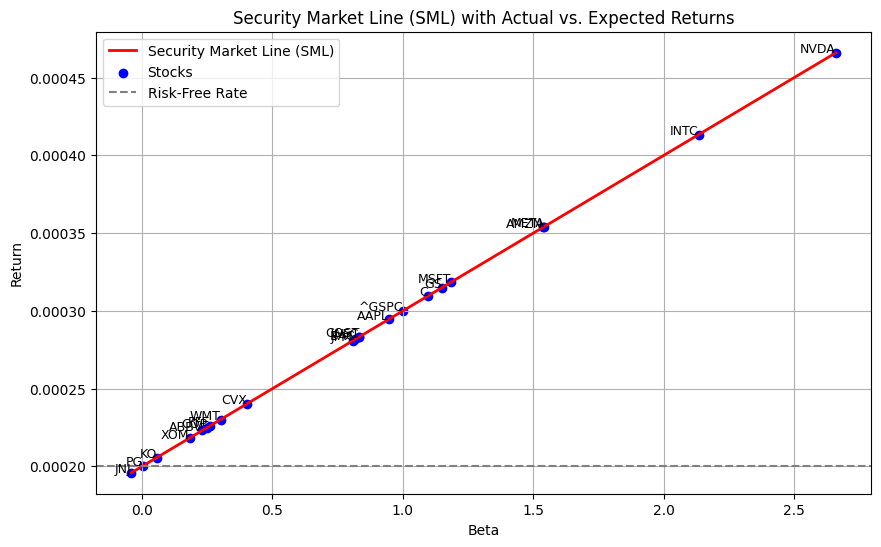

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize

#Assignment 2: Constructing the Security Market Line (SML)

#Task 1: Collect data for several stocks (at least 10) and the market index over the same period.

tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META',
           'JPM', 'BAC', 'GS', 'WFC', 'C',
           'XOM', 'CVX', 'COP',
           'JNJ', 'PFE', 'ABBV',
           'PG', 'KO', 'COST', 'WMT', 'INTC', '^GSPC']

data = yf.download(tickers, start='2024-01-01', end='2025-01-01')['Close']
data = data.dropna()
print(data.head())

#Task 2: Estimate the beta for each stock using the method from Assignment 1.

free_risk_rate = 0.0002

returns = data.pct_change().dropna()
excess_market_returns = returns['^GSPC'] - risk_free_rate
betas = {}

for stock in data.columns:
    excess_stock_returns = returns[stock] - risk_free_rate
    X = sm.add_constant(excess_market_returns)
    model = sm.OLS(excess_stock_returns, X, missing='drop').fit()
    betas[stock] = model.params['^GSPC']
    print(f"Estimated Beta for {stock}: {betas[stock]:.4f}")

betas_df = pd.DataFrame.from_dict(betas, orient='index', columns=['Beta'])
betas_df_sorted = betas_df.sort_values(by='Beta', ascending=False)

print("\nEstimates Betas (Sorted):")
print(betas_df_sorted)

#Task 3: Calculate the expected return for each stock using CAPM, assuming a given risk-free rate and market return.

risk_free_rate = 0.0002
market_return = 0.0003

betas_df_sorted['Expected_Return'] = risk_free_rate + betas_df_sorted['Beta'] * (market_return - risk_free_rate)

print("Expected Returns Using CAPM:")
print(betas_df_sorted[['Beta', 'Expected_Return']].sort_values(by='Expected_Return', ascending=False))

#Task 4: Plot the Security Market Line (SML) with the stocks' betas on the x-axis and their expected returns on the y-axis.

plt.figure(figsize=(10, 6))

plt.plot(betas_df_sorted['Beta'], betas_df_sorted['Expected_Return'], label='Security Market Line (SML)', color='red', lw=2)
plt.scatter(betas_df_sorted['Beta'], betas_df_sorted['Expected_Return'], color='blue', marker='o', label='Stocks')

for stock, row in betas_df_sorted.iterrows(): plt.annotate(stock, (row['Beta'], row['Expected_Return']), fontsize=9, ha='right')

plt.title('Security Market Line (SML) with Actual vs. Expected Returns')
plt.xlabel('Beta')
plt.ylabel('Return')
plt.axhline(y=risk_free_rate, color='gray', linestyle='--', label='Risk-Free Rate')
plt.grid(True)
plt.legend()
plt.show()

#Highlight stocks on the SML and discuss whether any stocks appear mispriced based on their position relative to the SML.

#No stocks significantly diverge from the SML, implying a mostly efficient market with correctly priced assets. This, to an extent, is the result of using the CAPM model to calculate returns.

[*********************100%***********************]  22 of 22 completed


Ticker            AAPL        ABBV        AMZN        BAC          C  \
Date                                                                   
2024-01-02  184.532089  152.743393  149.929993  32.851429  50.784550   
2024-01-03  183.150375  153.355087  148.470001  32.492874  51.359032   
2024-01-04  180.824341  154.310791  144.570007  32.754524  51.483505   
2024-01-05  180.098694  154.960678  145.240005  33.365032  52.019695   
2024-01-08  184.452560  154.282104  149.100006  33.103386  51.713299   

Ticker             COP        COST         CVX          GS       INTC  ...  \
Date                                                                   ...   
2024-01-02  113.465714  646.158203  141.734131  377.245636  47.168285  ...   
2024-01-03  115.723640  640.239319  144.436478  370.920990  46.428192  ...   
2024-01-04  112.394653  643.874023  142.852997  372.047943  46.250576  ...   
2024-01-05  112.442894  651.481201  142.606461  375.438568  46.270309  ...   
2024-01-08  110.484085  657

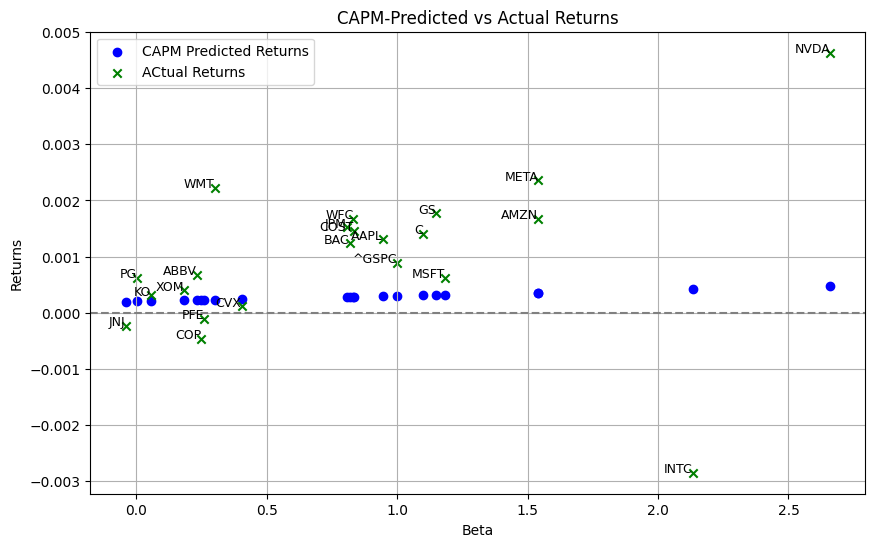

T-statistic: 2.3423
P-value: 0.0291
Reject the null hypothesis.


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy import stats

#Assignment 3: Testing CAPM's Predictions

#Task 1: Choose a sample of stocks from different sectors and download their historical and market index returns data.

tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META',
           'JPM', 'BAC', 'GS', 'WFC', 'C',
           'XOM', 'CVX', 'COP',
           'JNJ', 'PFE', 'ABBV',
           'PG', 'KO', 'COST', 'WMT', 'INTC', '^GSPC']

data = yf.download(tickers, start='2024-01-01', end='2025-01-01')['Close']
data = data.dropna()
print(data.head())

#Task 2: Estimate the beta for each stock and calculate the expected returns using CAPM.

risk_free_rate = 0.0002
market_return = 0.0003

betas = {}

for stock in data.columns:
  excess_stock_returns = returns[stock] - risk_free_rate
  excess_market_returns = returns['^GSPC'] - risk_free_rate
  X = sm.add_constant(excess_market_returns)
  model = sm.OLS(excess_stock_returns, X).fit()

  beta = model.params.iloc[1]
  betas[stock] = beta

betas_df = pd.DataFrame.from_dict(betas, orient='index', columns=['Beta'])
betas_df['Expected_Return'] = risk_free_rate + betas_df['Beta'] * (market_return - risk_free_rate)

#Task 3: Compare the CAPM-predicted returns with the actual average returns over the period.

betas_df['Actual_Return'] = returns.mean()

comparison_df = betas_df[['Beta', 'Expected_Return', 'Actual_Return']]

print(comparison_df)

plt.figure(figsize=(10,6))
plt.scatter(betas_df['Beta'], betas_df['Expected_Return'], color='blue', marker='o', label='CAPM Predicted Returns')

plt.scatter(betas_df['Beta'], betas_df['Actual_Return'], color='green', marker = 'x', label='ACtual Returns')

for stock, row in betas_df.iterrows(): plt.annotate(stock, (row['Beta'], row['Actual_Return']), fontsize=9, ha='right')

plt.axhline(y=0, color='gray', linestyle='--')
plt.title('CAPM-Predicted vs Actual Returns')
plt.xlabel('Beta')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

#Task 4: Use Python to conduct a hypothesis test to determine if there is a significant difference between the CAPM-predicted returns and actual returns.

expected_returns = betas_df['Expected_Return']
actual_returns = betas_df['Actual_Return']

t_stat, p_value = stats.ttest_rel(actual_returns, expected_returns)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
  print("Reject the null hypothesis.")
else:
  print("Fail to reject the null hypothesis.")

#Task 5: Discuss the findings and implications for the vailidity of CAPM in this context.

#We reject the null hypothesis at p=0.05. Thus, there is a significant difference between the CAPM-predicted returns and actual returns. Furthermore, on our plot, most stocks diverge from the SML significantly. This implies that CAPM is an invalid model for the prediction of return given risk.